In [ ]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

**데이터 준비 및 전처리**

In [ ]:
BATCH_SIZE = 128
NUM_CLASSES = 10
NUM_EPOCHS = 2

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

y_train = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test = keras.utils.to_categorical(y_test, NUM_CLASSES)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**CNN(합성곱 신경망) 모델 구조 설계**

In [ ]:
model = Sequential()
from keras.layers import Input
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(32, kernel_size = (3, 3), activation='relu'))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(NUM_CLASSES, activation='softmax'))

**모델 컴파일 / 학습 진행**

In [ ]:
model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("CNN 모델 학습을 시작합니다...")

# model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=NUM_EPOCHS, verbose=1)
model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=10, verbose=1)

CNN 모델 학습을 시작합니다...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9281 - loss: 0.2390
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9748 - loss: 0.0849
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9808 - loss: 0.0648
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9837 - loss: 0.0526
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9865 - loss: 0.0433
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9882 - loss: 0.0384
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9893 - loss: 0.0330
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9897 - loss: 0.0309
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9915 - loss: 0.0274
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9920 - loss: 0.0252


**모델 성능 평가**

In [ ]:
cnn_score = model.evaluate(x_test, y_test, verbose=0)
print('최종 테스트 정확도(Accuracy): %.2f%%' % (cnn_score[1] * 100))

최종 테스트 정확도(Accuracy): 99.23%


**그림판으로 구현(추가)**

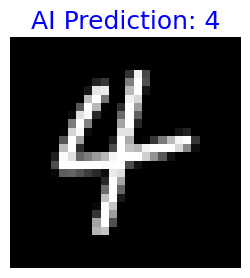

인공지능 예측 결과: 4
각 숫자별 확률:
0: 0.0%
1: 0.0%
2: 0.0%
3: 0.0%
4: 100.0%
5: 0.0%
6: 0.0%
7: 0.0%
8: 0.0%
9: 0.0%




In [ ]:
from IPython.display import HTML, display, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
import tensorflow as tf

def get_canvas_input():

    """
    Displays an HTML canvas for user input, captures drawing, and returns the
    base64 encoded image data or an "EXIT" signal.
    """
    uid = int(time.time() * 1000)

    canvas_html = f"""
    <div style="display:flex; flex-direction:column; align-items:center; border: 2px solid #ddd; padding: 20px; border-radius: 10px; width: max-content;">
        <h3 style="margin-top:0;">마우스로 숫자를 그려보세요 (0~9)</h3>
        <canvas id="canvas_{uid}" width="280" height="280" style="border: 1px solid black; background-color: black; cursor: crosshair; touch-action: none;"></canvas>
        <div style="margin-top: 15px;">
            <button id="clear_btn_{uid}" style="padding: 10px 20px; margin-right: 10px; font-weight: bold;">지우기</button>
            <button id="predict_btn_{uid}" style="padding: 10px 20px; margin-right: 10px; font-weight: bold; color: white; background-color: #4285F4; border: none; border-radius: 5px;">예측하기</button>
            <button id="exit_btn_{uid}" style="padding: 10px 20px; font-weight: bold; color: white; background-color: #EA4335; border: none; border-radius: 5px;">종료</button>
        </div>
    </div>
    <script>
    var canvas = document.getElementById('canvas_{uid}');
    var ctx = canvas.getContext('2d');
    ctx.lineWidth = 15;
    ctx.lineCap = 'round';
    ctx.lineJoin = 'round';
    ctx.strokeStyle = 'white';

    var drawing = false;
    var pos = {{ x: 0, y: 0 }};

    function setPosition(e) {{
        var rect = canvas.getBoundingClientRect();
        pos.x = (e.clientX || e.touches[0].clientX) - rect.left;
        pos.y = (e.clientY || e.touches[0].clientY) - rect.top;
    }}

    function draw(e) {{
        if (!drawing) return;
        e.preventDefault();
        ctx.beginPath();
        ctx.moveTo(pos.x, pos.y);
        setPosition(e);
        ctx.lineTo(pos.x, pos.y);
        ctx.stroke();
    }}

    canvas.addEventListener('mousedown', function(e) {{ drawing = true; setPosition(e); }});
    canvas.addEventListener('mousemove', draw);
    canvas.addEventListener('mouseup', function(e) {{ drawing = false; }});
    canvas.addEventListener('mouseout', function(e) {{ drawing = false; }});

    canvas.addEventListener('touchstart', function(e) {{ drawing = true; setPosition(e); }}, {{passive: false}});
    canvas.addEventListener('touchmove', draw, {{passive: false}});
    canvas.addEventListener('touchend', function(e) {{ drawing = false; }});

    document.getElementById('clear_btn_{uid}').addEventListener('click', function() {{
        ctx.clearRect(0, 0, canvas.width, canvas.height);
    }});

    var promise_{uid} = new Promise(resolve => {{
        document.getElementById('predict_btn_{uid}').onclick = () => resolve(canvas.toDataURL('image/png'));
        document.getElementById('exit_btn_{uid}').onclick = () => resolve("EXIT");
    }});
    </script>
    """
    clear_output(wait=True)
    display(HTML(canvas_html))
    data = eval_js(f'promise_{uid}')
    return data, uid

def crop_and_pad_image(img):
    """
    Crops the image to the bounding box of non-black pixels and pads it to maintain aspect ratio,
    then resizes it to 20x20 centered on a 28x28 canvas.
    """
    # Find all non-zero pixels
    coords = cv2.findNonZero(img)
    x, y, w, h = cv2.boundingRect(coords)

    # Crop the image to the bounding box
    cropped_img = img[y:y+h, x:x+w]

    # Make the cropped image square by adding padding
    side = max(w, h)
    square_img = np.zeros((side, side), dtype=np.uint8)
    x_offset = (side - w) // 2
    y_offset = (side - h) // 2
    square_img[y_offset:y_offset+h, x_offset:x_offset+w] = cropped_img

    # Resize the square image to 20x20
    resized_img = cv2.resize(square_img, (20, 20), interpolation=cv2.INTER_AREA)

    # Pad to 28x28 canvas, centering the 20x20 image
    final_img = np.zeros((28, 28), dtype=np.uint8)
    final_img[4:24, 4:24] = resized_img

    return final_img

def preprocess_image_for_model(base64_data):
    """
    Decodes a base64 image, applies cropping and padding, normalizes pixel values,
    and converts it to a TensorFlow tensor suitable for the model.
    Returns the processed tensor and the resized grayscale image for display.
    """
    binary = b64decode(base64_data.split(',')[1])
    img_array = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None, None

    # Set this flag to True to use cropping and padding, False to use simple resizing
    USE_CROP_AND_PAD = True

    if USE_CROP_AND_PAD:
        img = crop_and_pad_image(img)
    else:
        # Simple resize to 28x28 if not using crop and pad
        img = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)

    input_array = img.astype(np.float32).reshape(1, 28, 28, 1) / 255.0
    input_tensor = tf.convert_to_tensor(input_array)
    return input_tensor, img

def get_model_prediction_and_display_results(model, input_tensor, img_resized):
    """
    Feeds the processed image to the model, gets predictions, and displays
    the predicted number along with the image and probability distribution.
    """
    prediction = model(input_tensor, training=False).numpy()
    predicted_number = np.argmax(prediction)

    plt.figure(figsize=(3, 3))
    plt.imshow(img_resized, cmap='gray')
    plt.title(f"AI Prediction: {predicted_number}", fontsize=18, color='blue')
    plt.axis('off')
    plt.show()

    print(f"인공지능 예측 결과: {predicted_number}")
    print("각 숫자별 확률:")
    for i, prob in enumerate(prediction[0]):
        print(f"{i}: {prob * 100:.1f}%")
    print("\n")
    return predicted_number, prediction

def prompt_for_next_action(uid):
    """
    Displays buttons for continuing or exiting the canvas interaction
    and waits for user input.
    """
    next_html = f"""
    <div style="margin-top: 10px;">
        <button id="next_btn_{uid}" style="padding: 10px 20px; font-weight: bold; background-color: #34A853; color: white; border: none; border-radius: 5px; margin-right: 10px;">새 캔버스 열기</button>
        <button id="exit2_btn_{uid}" style="padding: 10px 20px; font-weight: bold; background-color: #EA4335; color: white; border: none; border-radius: 5px;">테스트 종료</button>
    </div>
    <script>
    var next_p_{uid} = new Promise(resolve => {{
        document.getElementById('next_btn_{uid}').onclick = () => resolve("NEXT");
        document.getElementById('exit2_btn_{uid}').onclick = () => resolve("EXIT");
    }});
    </script>
    """
    display(HTML(next_html))
    action = eval_js(f'next_p_{uid}')
    return action

def run_canvas_inference(model):
    while True:
        data, uid = get_canvas_input()

        if data == "EXIT":
            clear_output(wait=True)
            break

        input_tensor, img_resized = preprocess_image_for_model(data)
        if input_tensor is None:
            # This can happen if imdecode fails (e.g., malformed image data, though unlikely from canvas)
            continue

        predicted_number, prediction = get_model_prediction_and_display_results(model, input_tensor, img_resized)

        action = prompt_for_next_action(uid)
        if action == "EXIT":
            clear_output(wait=True)
            break

run_canvas_inference(model)